# 03. Python Setup and Data

This chapter makes sure your Python environment can run the examples in this module.

By the end, you should be able to:

- import the required Python packages,
- load the course data from a relative path,
- inspect columns and data types,
- run a small feedback check.

## Load the browser Python packages

Run the next cell once near the start of the module. It loads the scientific Python packages used in these notebooks into the browser-based Python kernel.

In [1]:
from lite_setup import ensure_packages
await ensure_packages()


Using the current Python environment.


After the package setup finishes, continue with the import check below.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

from checks import check, check_columns

print("Imports are ready.")

Imports are ready.


## Load the fuel consumption data

The data file is stored with this module, so the same relative path works on any computer when the files stay together.

In [3]:
fuel = pd.read_csv("data/fuelcons.csv")
fuel

,week,Temp,Fuelcons
0,1,28.0,12.4
1,2,28.0,11.7
2,3,32.5,12.4
3,4,39.0,10.8
4,5,45.9,9.4
5,6,57.8,9.5
6,7,58.1,8.0
7,8,62.5,7.5


The data set has one row per week.

- `week`: observation order
- `Temp`: weekly temperature
- `Fuelcons`: weekly fuel consumption

In [4]:
print(fuel.shape)
print(fuel.dtypes)

(8, 3)
week          int64
Temp        float64
Fuelcons    float64
dtype: object


## Check the data structure

In [5]:
print(check_columns(fuel, ["week", "Temp", "Fuelcons"]))
print(check(fuel.shape[0] >= 8, "The data set has enough rows for this example.", "The data set looks too small or did not load correctly."))

PASS: Found the required columns: week, Temp, Fuelcons.
PASS: The data set has enough rows for this example.


## First look

Always look at the data before fitting a regression model.

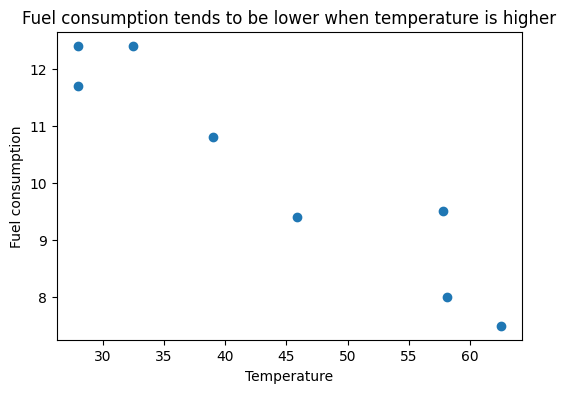

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(fuel["Temp"], fuel["Fuelcons"])
ax.set_xlabel("Temperature")
ax.set_ylabel("Fuel consumption")
ax.set_title("Fuel consumption tends to be lower when temperature is higher")
plt.show()

## Check your understanding

Before fitting a model, answer this from the plot:

> Do you expect the regression slope to be positive or negative?

The scatter plot slopes downward: higher temperatures tend to appear with lower fuel consumption. The code below computes the sample correlation as a quick numerical summary of that same pattern.

In [7]:
correlation = fuel["Temp"].corr(fuel["Fuelcons"])
direction = "negative" if correlation < 0 else "positive"

print(f"Sample correlation between Temp and Fuelcons: {correlation:.3f}")
print(f"The fitted slope should be {direction}.")

Sample correlation between Temp and Fuelcons: -0.948
The fitted slope should be negative.


## What to remember

If you can import packages, load data with a relative path, inspect the data, and make the first plot, you are ready to fit the model.